In [73]:
%matplotlib inline

In [4]:
import numpy as np
import glob
import json
from pyquaternion import Quaternion
from pcdet.models import build_network
from pcdet.config import (cfg, cfg_from_list, cfg_from_yaml_file,log_config_to_file)
from pcdet.datasets import build_dataloader, DatasetTemplate
from pcdet.utils import common_utils
import torch
from scipy.spatial.transform import Rotation
from matplotlib.patches import Polygon
from matplotlib import pyplot as plt
import os
import pickle
import copy 
#from pytorch3d.ops import box3d_overlap
from scipy.optimize import linear_sum_assignment
import pandas as pd
from tqdm import tqdm
import time
from annotell.apiclients.scene_input_api_client import SceneInputApiClient
from annotell.potree_filestorage.potree_filestorage import PotreeFileStorage, MissingAttributeError
from annotell.filestorage.filestorage import FileStorage, FileId
from annotell.apiclients.EngineApi import EngineApi
from annotell.potree.potree import PointAttributes
from annotell.projection.calibration import CameraCalibration, Calibration
from annotell.projection.projection import project_lidar_to_image
from typing import Optional, List
import uuid
from annotell.apiclients.scene_input_api_client import SceneInputApiClient
from annotell.potree_filestorage.potree_filestorage import PotreeFileStorage, MissingAttributeError
from annotell.filestorage.filestorage import FileStorage, FileId
from annotell.apiclients.EngineApi import EngineApi
from annotell.potree.potree import PointAttributes
from annotell.projection.calibration import CameraCalibration, Calibration
from annotell.projection.projection import project_lidar_to_image
from typing import Optional, List

logger = common_utils.create_logger('../temp',rank=cfg.LOCAL_RANK)

fatal: unsafe repository ('/root/luca' is owned by someone else)
To add an exception for this directory, call:

	git config --global --add safe.directory /root/luca
/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Utility functions

In [5]:
def filter_zeroarea_cuboids(cuboids):
    filt_cuboids = []
    for cuboid in cuboids:
        if np.sum(cuboid['dimensions']) > 0:
            filt_cuboids.append(cuboid)
    return filt_cuboids


def filter_score_cuboids(cuboids, threshold):
    filt_cuboids = []
    for cuboid in cuboids:
        score = cuboid['score'][0]
        if score >= threshold:
            filt_cuboids.append(cuboid)
    return filt_cuboids


def corners_iou(cuboids):
    corn_tensor = []
    for cuboid in cuboids:
        position = cuboid['location']
        rotation = cuboid['rotation']
        h, w, l = cuboid['dimensions']        
        corners = np.zeros((3, 8))
        corners[0, :] = l / 2 * np.array([-1, 1, 1, -1, -1, 1, 1, -1])  # x_corners
        corners[1, :] = w / 2 * np.array([-1, -1, -1, -1, 1, 1, 1, 1])  # y_corners
        corners[2, :] = h / 2 * np.array([1, 1, -1, -1, 1, 1, -1, -1])  # z_corners
        corners = cuboid['rotation'][:3,:3] @ corners + cuboid['location'].reshape((3, -1))
        corn_tensor.append(corners.T)

    corn_tensor = np.stack(corn_tensor)
    corners = torch.from_numpy(corn_tensor)
    

    return corners.to(torch.float32)


def get_stats_error(gt, pred, score_thresh=0.5, iou_thresh=0.5):
    pred = copy.deepcopy(pred)
    gt = copy.deepcopy(gt)

    pred = filter_zeroarea_cuboids(pred)
    gt = filter_zeroarea_cuboids(gt)

    pred = filter_score_cuboids(pred, score_thresh)
    
    pred_corners = corners_iou(pred)
    gt_corners = corners_iou(gt)

    intersection_vol, iou_3d = box3d_overlap(pred_corners, gt_corners)

    tp_cuboid = []
    fp_cuboid = []
    fn_cuboid = []
    tp_cuboid_gt = []
    
    fp = 0
    fn = 0
    tp = 0
    p = len(gt)


    row_ind, col_ind = linear_sum_assignment(-iou_3d)

    for j in range(len(row_ind)):
        gt_curr = gt[col_ind[j]]
        pred_curr = pred[row_ind[j]]
        iou_curr = iou_3d[row_ind[j],col_ind[j]]
        if iou_curr > iou_thresh:
            tp += 1
            tp_cuboid.append(pred_curr)
            tp_cuboid_gt.append(gt_curr)
        else:
            fp += 1
            fn += 1
            fp_cuboid.append(pred_curr)
            fn_cuboid.append(gt_curr)

    all_pred_idxes = np.arange(len(pred)).astype(int)
    extra_fp = np.setdiff1d(all_pred_idxes, row_ind)
    for idx in extra_fp:
        fp_cuboid.append(pred[idx])


    all_gt_idxes = np.arange(len(gt)).astype(int)
    extra_fn = np.setdiff1d(all_gt_idxes, col_ind)
    for idx in extra_fn:
        fn_cuboid.append(gt[idx])

            
    if len(gt) > len(pred):
        fn += len(gt) - len(pred)
    if len(gt) < len(pred):
        fp += len(pred) - len(gt)
    
    rec = tp/p
    pre = tp/(tp+fp)    
    
    return np.round(pre*10000)/100, np.round(rec*10000)/100, tp_cuboid, tp_cuboid_gt, fp_cuboid, fn_cuboid

In [6]:
def get_detections(pred_dicts, threshold):
    labels = pred_dicts[0]["pred_labels"].cpu().numpy()
    confs = pred_dicts[0]["pred_scores"].cpu().numpy()
    boxes = pred_dicts[0]["pred_boxes"].cpu().numpy()
    objs = []

    for lab, score, box in zip(labels, confs, boxes):
        length, width, height = box[3:6]
        # ISO x,y,z,rot
        x, y, z = box[0:3]
        rot = box[-1]
        obj = {}
        obj['class'] = int(lab - 1)
        obj['location'] = np.array([x, y, z])
        obj['dimensions'] = np.array([length, height, width])
        obj['rotation'] = Rotation.from_euler('z', rot, degrees=False).as_matrix()
        obj['score'] = [score]
        if score >= threshold:
            objs.append(obj)
    return objs

def get_gt_boxes(data):
    objs = []
    for i in range(0, len(data['gt_boxes'][0])):
        box = data['gt_boxes'][0][i].cpu().numpy()
        length, width, height = box[3:6]
        # ISO x,y,z,rot
        x, y, z = box[0:3]
        rot = box[-2]
        obj = {}
        obj['location'] = np.array([x, y, z])
        obj['dimensions'] = np.array([length, height, width])
        obj['rotation'] = Rotation.from_euler('z', rot, degrees=False).as_matrix()
        obj['class'] = int(box[-1] - 1)
        objs.append(obj)
    return objs

def get_gt_boxes_fromfile(lid_path):
    annotation_file = lid_path.replace('pcs', 'dataframes').replace('.npy', '.pkl')
    judgement = pd.read_pickle(annotation_file)
    objs = []
    for i in range(0, len(judgement)):
        curr_obj = judgement.iloc[i]
        if curr_obj['source'] == '@lidar':
            obj_class = _parse_class(curr_obj)
            if obj_class is None:
                continue
            if curr_obj['shape_type'] == 'Cube3D':
                coordinates = curr_obj['Cube3D_coordinates'].copy()
                w, l, h = curr_obj['Cube3D_scale']
                coordinates[0], coordinates[1] = coordinates[1], -coordinates[0]
                rotation = Rotation.from_quat(curr_obj['Cube3D_rotation']).as_euler('xyz')[2] - np.pi / 2
                obj = {}
                obj['location'] = np.array(coordinates)
                obj['dimensions'] = np.array([l, h, w])
                obj['rotation'] =   Rotation.from_euler('z', rotation, degrees=False).as_matrix()
                objs.append(obj)
    return objs

In [7]:
def prepare_data(pointcloud, dat):
    pointcloud = np.c_[pointcloud[:,0],pointcloud[:,1],pointcloud[:,2]-1.2, pointcloud[:,3]/2**16]
    input_dict = {}
    input_dict["points"] = torch.from_numpy(pointcloud).float()
    input_dict = dat.prepare_data(input_dict)
    input_dict = dat.collate_batch([input_dict])
    return load_data_to_gpu(input_dict)


def load_data_to_gpu(batch_dict):
    for key, val in batch_dict.items():
        if not isinstance(val, np.ndarray):
            continue
        elif key in ['frame_id', 'metadata', 'calib']:
            continue
        elif key in ['images']:
            batch_dict[key] = kornia.image_to_tensor(val).float().cuda().contiguous()
        elif key in ['image_shape']:
            batch_dict[key] = torch.from_numpy(val).int().cuda()
        else:
            batch_dict[key] = torch.from_numpy(val).float().cuda()
    return batch_dict

def bottom_corners(cuboid):
    corners = np.zeros((2, 4))
    l, h, w = cuboid['dimensions']
    corners[0, :] = w / 2 * np.array([-1, 1, 1, -1])  # x_corners
    corners[1, :] = l / 2 * np.array([-1, -1, 1, 1])  # y_corners

    # Rotate & Translate
    corners = cuboid['rotation'][:2,:2] @ corners + cuboid['location'][:2].reshape((2, -1))
    poly = np.stack([corners[0], corners[1]]).T
    return poly

def _parse_class(obj):
    obj_cls = obj["class"]
    if obj_cls not in ("VulnerableVehicle", "Vehicle", "Pedestrian"):
        return None
    elif obj_cls == "VulnerableVehicle":
        obj_cls = "Cyclist"
        # Remove stuff without rider
        if obj.get("with_rider", "True") == "False":
            return None
    elif obj_cls == "Vehicle":
        # No special treatment for pedestrians
        pass
    elif obj_cls == "Pedestrian":
        # No special treatment for pedestrians
        pass
    return obj_cls

# Load dataset and 3DOD model

In [6]:
os.chdir('/root/OpenPCDet/tools/')

In [7]:
dist_test = False
cfg_from_yaml_file('cfgs/cosmos_models/pv_rcnn_plusplus_eval.yaml', cfg);
model_path = '/root/OpenPCDet/output/cosmos_models/pv_rcnn_train/fisheye/ckpt/checkpoint_epoch_9.pth'
test_set, test_loader, sampler = build_dataloader(
    dataset_cfg=cfg.DATA_CONFIG,
    class_names=cfg.CLASS_NAMES,
    batch_size=4,
    dist=dist_test, workers=4, logger=logger, training=False)

dat = DatasetTemplate(dataset_cfg=cfg.DATA_CONFIG,
    class_names=cfg.CLASS_NAMES, training=False)

model = build_network(model_cfg=cfg.MODEL, num_class=len(cfg.CLASS_NAMES), dataset=test_set)
model.load_params_from_file(filename=model_path, logger=logger,to_cpu=dist_test)
model.cuda();
model.eval();

/root/.local/lib/python3.8/site-packages/torch/functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
2022-05-22 18:16:50,956   INFO  ==> Loading parameters from checkpoint /root/OpenPCDet/output/cosmos_models/pv_rcnn_train/fisheye/ckpt/checkpoint_epoch_9.pth to GPU
2022-05-22 18:16:51,111   INFO  ==> Checkpoint trained from version: pcdet+0.5.2+0d97887
2022-05-22 18:16:51,139   INFO  ==> Done (loaded 391/391)


# Evaluate single example from dataloader

In [ ]:
idx = 9
with torch.no_grad():
    data = load_data_to_gpu(dat.collate_batch([test_set[idx]]))
    pred_dicts, ret_dict = model(data)
    

pred = get_detections(pred_dicts, threshold=0.2)
gt = get_gt_boxes(data)
    
pre, rec, tp_cuboid, tp_cuboid_gt, fp_cuboid, fn_cuboid = get_stats_error(gt, pred, score_thresh=0.0, iou_thresh=0.5)
    
pointcloud = data['points'].cpu().numpy()[:,1:4]
fig, ax = plt.subplots(figsize=(20,20))
ax.plot(pointcloud[:,0], pointcloud[:,1],'.', markersize=0.2)

for obj in tp_cuboid:
    poly = bottom_corners(obj)
    ax.add_patch(Polygon(poly, edgecolor = 'green', fill=False,lw=4,closed=True))

for obj in fp_cuboid:
    poly = bottom_corners(obj)
    ax.add_patch(Polygon(poly, edgecolor = 'blue', fill=False,lw=4,closed=True))
    
for obj in fn_cuboid:
    poly = bottom_corners(obj)
    ax.add_patch(Polygon(poly, edgecolor = 'red', fill=False,lw=4,closed=True))    
    
ax.set_aspect('equal');
ax.set_xlim([0, 130]);
ax.set_ylim([-50, 50]);

# Process all dataset

In [194]:
PRE, REC, TP, TP_GT, FP, FN = [], [], [], [], [], []
for idx in tqdm(range(len(test_set))):
    with torch.no_grad():
        data = load_data_to_gpu(dat.collate_batch([test_set[idx]]))
        pred_dicts, ret_dict = model(data)
    pred = get_detections(pred_dicts)
    gt = get_gt_boxes(data)

    if len(pred_dicts[0]['pred_boxes']) > 0:
        pre, rec, tp_cuboid, tp_cuboid_gt, fp_cuboid, fn_cuboid = get_stats_error(gt, pred, score_thresh=0.0, iou_thresh=0.5)
        PRE.append(pre)
        REC.append(rec)
        TP.append(tp_cuboid)
        TP_GT.append(tp_cuboid_gt)
        FP.append(fp_cuboid)
        FN.append(fn_cuboid)
    else:
        PRE.append(0)
        REC.append(0)
        TP.append([])
        TP_GT.append([])
        FP.append([])
        FN.append(gt)

all_data = {'PRE':PRE, 'REC':REC, 'TP':TP, 'TP_GT':TP_GT, 'FP':FP, 'FN':FN}
with open(f'all_data_{time.time_ns()}.pickle','wb') as f:
    pickle.dump(all_data,f)

100%|██████████| 31781/31781 [1:11:52<00:00,  7.37it/s]


In [198]:
# with open('all_data.pickle','rb') as f:
#     test = pickle.load(f)

# Evaluate from file

In [30]:
LIDAR_POINTCLOUD_SEQ_FILES = glob.glob('/mnt/bfd/luca/cosmos_data_3dod/**/*.npy', recursive=True)

In [ ]:
idx = 4800
lid_path = LIDAR_POINTCLOUD_SEQ_FILES[idx]
pointcloud = np.load(lid_path, allow_pickle=True)
data, pointcloud = prepare_data(pointcloud, cfg)
with torch.no_grad():
    pred_dicts, ret_dict = model(data)
    
pred = get_detections(pred_dicts)
gt = get_gt_boxes_fromfile(lid_path)
    
pre, rec, tp_cuboid, tp_cuboid_gt, fp_cuboid, fn_cuboid = get_stats_error(gt, pred, score_thresh=0.0, iou_thresh=0.5)
    
pointcloud = data['points'].cpu().numpy()[:,1:4]
fig, ax = plt.subplots(figsize=(20,20))
ax.plot(pointcloud[:,0], pointcloud[:,1],'.', markersize=0.2)

for obj in tp_cuboid:
    poly = bottom_corners(obj)
    ax.add_patch(Polygon(poly, edgecolor = 'green', fill=False,lw=4,closed=True))

for obj in fp_cuboid:
    poly = bottom_corners(obj)
    ax.add_patch(Polygon(poly, edgecolor = 'blue', fill=False,lw=4,closed=True))
    
for obj in fn_cuboid:
    poly = bottom_corners(obj)
    ax.add_patch(Polygon(poly, edgecolor = 'red', fill=False,lw=4,closed=True))    
    
ax.set_aspect('equal');
ax.set_xlim([0, 130]);
ax.set_ylim([-50, 50]);

# Get judgement id for data example

In [31]:
filename = test_set.annotations[data['frame_id'][0]][0]
judgement_id = filename.split('/')[-1].split('.')[0].split('_')[1]
print(judgement_id)

4990900


# Find assignment id from judgement id

In [11]:
from annotell.apiclients.EngineApi import EngineApi
env = 'production'
engine_api_client = EngineApi(env=env)
judgement_id = 4990900
assign_id = engine_api_client.get_assignment_from_judgement_id(judgement_id).id
print(assign_id)

7032242


# Download judgement json blob

In [130]:
from annotell.apiclients.judgement_api_client import JudgementApiClient
jdg = JudgementApiClient(env=env)
j_json = jdg.get_judgement_content(5115673)

# Download judgement as dataframe

In [135]:
def to_kebab_case_dataframe(df):
    if "ObjectType" in df:
        df.rename({"ObjectType": "object_type"}, axis='columns', inplace=True)
    if "Unclear" in df:
        df.rename({"Unclear": "unclear"}, axis='columns', inplace=True)
    if "OcclusionRatio" in df:
        df.rename({"OcclusionRatio": "occlusion_ratio"}, axis='columns', inplace=True)
    if "WithRider" in df:
        df.rename({"WithRider": "with_rider"}, axis='columns', inplace=True)
    if "Pose" in df:
        df.rename({"Pose": "pose"}, axis='columns', inplace=True)
    if "Odd" in df:
        df.rename({"Odd": "odd"}, axis='columns', inplace=True)
    if "CornerPoint" in df:
        df.rename({"CornerPoint": "corner_point"}, axis='columns', inplace=True)
    if "RelativePosition" in df:
        df.rename({"RelativePosition": "relative_position"}, axis='columns', inplace=True)
    if "IsPullingOrPushing" in df:
        df.rename({"IsPullingOrPushing": "is_pulling_or_pushing"}, axis='columns', inplace=True)
    if "Emergency" in df:
        df.rename({"Emergency": "emergency"}, axis='columns', inplace=True)
    if "CornerPoint" in df:
        df.rename({"CornerPoint": "corner_point"}, axis='columns', inplace=True)
    if "Posture" in df:
        df.rename({"Posture": "posture"}, axis='columns', inplace=True)
    return df

In [ ]:
from annotell.apiclients.EngineApi import EngineApi
from annotell.task_definition.task_def_cache import TaskDefCache
from annotell.judgement_dataframe.dataframe_creator import JudgementDataFrameCreator

eng = EngineApi(env=env)
td_cache = TaskDefCache(eng)

def get_judge_dataframe(judgement_id):
    res = eng.get_judgement_with_assignment_from_judgement_id(judgement_id)
    td_id = res['judgement']['taskDefinitionId']
    td_rev_id = res['judgement']['taskDefinitionRevisionId']
    judgement_id = res['judgement']['id']
    judgement_content = jdg.get_judgement_content(judgement_id)
    if td_rev_id is None:
        td_rev_id = 1
    task_def = td_cache.get_task_def(td_id, td_rev_id)

    df_creator = JudgementDataFrameCreator(task_definition=task_def)
    df_creator.append_data(judgement=judgement_content, judgement_id=judgement_id)
    df = df_creator.to_typed_pandas()
    return to_kebab_case_dataframe(df)

j_df = get_judge_dataframe(5369561)

# Load annotation from dataframe

In [ ]:
annotation_file = lid_path.replace('pcs', 'boxes').replace('npy', 'json')
with open(annotation_file, 'r') as f:
    annotation = json.load(f)
shapes = annotation.get('shapes', dict())
objs = []
for shape in shapes['@lidar']['features']:
    geometry = shape['geometry']
    coordinates = geometry['coordinates'].copy()
    coordinates[0], coordinates[1] = coordinates[1], -coordinates[0]
    w, l, h = geometry['scale']
    rot = Rotation.from_quat(geometry['rotation']).as_euler('xyz')[2] - np.pi/2
    obj = {}
    obj['location'] = np.array(coordinates)
    obj['dimensions'] = np.array([l, h, w])
    obj['rotation'] =   Rotation.from_euler('z', rot, degrees=False).as_matrix()
    objs.append(obj)

In [ ]:
annotation_file = lid_path.replace('pcs', 'dataframes').replace('.npy', '.pkl')
judgement = pd.read_pickle(annotation_file)

objs = []
for i in range(0, len(judgement)):
    curr_obj = judgement.iloc[i]
    if curr_obj['source'] == '@lidar':
        obj_class = _parse_class(curr_obj)
        if obj_class is None:
            continue
        if curr_obj['shape_type'] == 'Cube3D':
            coordinates = curr_obj['Cube3D_coordinates'].copy()
            w, l, h = curr_obj['Cube3D_scale']
            coordinates[0], coordinates[1] = coordinates[1], -coordinates[0]
            rotation = Rotation.from_quat(curr_obj['Cube3D_rotation']).as_euler('xyz')[2] - np.pi / 2
            obj = {}
            obj['location'] = np.array(coordinates)
            obj['dimensions'] = np.array([l, h, w])
            obj['rotation'] =   Rotation.from_euler('z', rotation, degrees=False).as_matrix()
            objs.append(obj)

# Download data from input_id

In [8]:
def get_cam_name(calib):
    cam_names = []
    sensors = list(calib.calibration.keys())
    if 'MergedPointCloud' not in sensors:
        return None
    for source in sensors:
        if source != 'MergedPointCloud' and source is not None:
            cam_names.append(source)
    if len(cam_names) == 0:
        return None
    return cam_names

def read_pointcloud_from_bucket(file_id: FileId, attributes: Optional[List[PointAttributes]] = None) -> np.ndarray:
    num_retries = 3
    for i in range(num_retries):
        try:
            if attributes is None:
                attributes = [PointAttributes.POSITION_CARTESIAN, PointAttributes.INTENSITY]
            return potree_fs.get_potree_content(file_id, attributes)
        except ProtocolError as e:
            if i == num_retries - 1:
                raise Exception(f"Failed to read point cloud from fid: {file_id}") from e
        except MissingAttributeError as e:
            raise MissingAttributeError(
                f"Failed to read attributes {attributes} in potree from fid: {file_id}") from e
        except Exception as e:
            raise Exception(f"Failed to read point cloud from fid: {file_id}") from e

def get_pc(resources, input_internal_id):
    bucket_name = "annotell-files"
    pc_path = resources[0][1][0].resource_id.split(f'gs://{bucket_name}/')[1]
    download_id = FileId(source='gs',
                         bucket=bucket_name,
                         path=pc_path)
    pc = read_pointcloud_from_bucket(download_id)
    return pc

In [9]:
map_class_to_cosmos = {0:'Vehicle', 1:'Vehicle', 2:'Pedestrian', 3: 'VulnerableVehicle'}

def convert_to_cosmos(obj):    
    l, w, h = obj['dimensions'].astype(float)
    x, y, z = obj['location'].astype(float)
    angle = Rotation.from_matrix(obj['rotation']).as_euler('xyz')[2] + np.pi/2
    quat = Rotation.from_euler('z', angle).as_quat().astype(float).tolist()
    
    obj_to_cosmos = {}
    obj_to_cosmos['coordinates'] = [-y, x, z]
    obj_to_cosmos['scale'] = [h, l, w]
    obj_to_cosmos['rotation'] = quat
    obj_to_cosmos['class'] = map_class_to_cosmos[obj['class']]
    return obj_to_cosmos
    
def add_feature(data, obj):
    idobj = str(uuid.uuid4())
    
    feature = {}
    feature['id'] = idobj
    feature['properties'] = {}
    feature['properties']['@automationSource'] = 'pv_rcnn'
    
    feature['type'] = "feature"
    feature['geometry'] = {}
    feature['geometry']['type'] = 'Cube3D'
    obj_to_cosmos = convert_to_cosmos(obj)
    feature['geometry']['coordinates'] = obj_to_cosmos['coordinates']
    feature['geometry']['scale'] = obj_to_cosmos['scale']
    feature['geometry']['rotation'] = obj_to_cosmos['rotation']

    
    data['shapes']['@lidar']['features'].append(feature)
    data['shapeProperties'][idobj] = {}
    data['internalProperties'][idobj] = {}
    data['internalProperties'][idobj]['@created'] = time.time_ns()
    data['shapeProperties'][idobj]['@lidar'] = {}
    data['shapeProperties'][idobj]['@all'] = {}
    data['shapeProperties'][idobj]['@all']['class'] = obj_to_cosmos['class']
    data['shapeProperties'][idobj]['@all']['unclear'] = False  
    return data

def generate_preannotation_blob(objs):
    data = {}
    data['shapes'] = {}
    data['shapes']['@lidar'] = {}
    data['shapes']['@lidar']['features'] = []

    data['certainty'] = 'sure'
    data['properties'] = {}
    data['properties']['@lidar'] = {}
    data['properties']['@all'] = {}

    data['shapeProperties'] = {}
    data['internalProperties'] = {}

    for i,obj in enumerate(objs):
        add_feature(data, obj)
    return data

def get_predictions(input_internal_id, threshold):
    scene = scn.get_scene(input_internal_id)
    resources = list(scene.get_resources_per_frame())
    pc = get_pc(resources, input_internal_id)

    with torch.no_grad():
        data = prepare_data(pc, dat)
        pred_dicts, ret_dict = model(data)

    pred = get_detections(pred_dicts, threshold)    
    pointcloud = data['points'].cpu().numpy()[:,1:5]
    
    return pred, pointcloud

In [9]:
env = 'production'
eng = EngineApi(env=env)
scn = SceneInputApiClient(env=env)
potree_fs = PotreeFileStorage()

request_id = 2215
task_definition_id = 565
task_definition_revision_id = 1

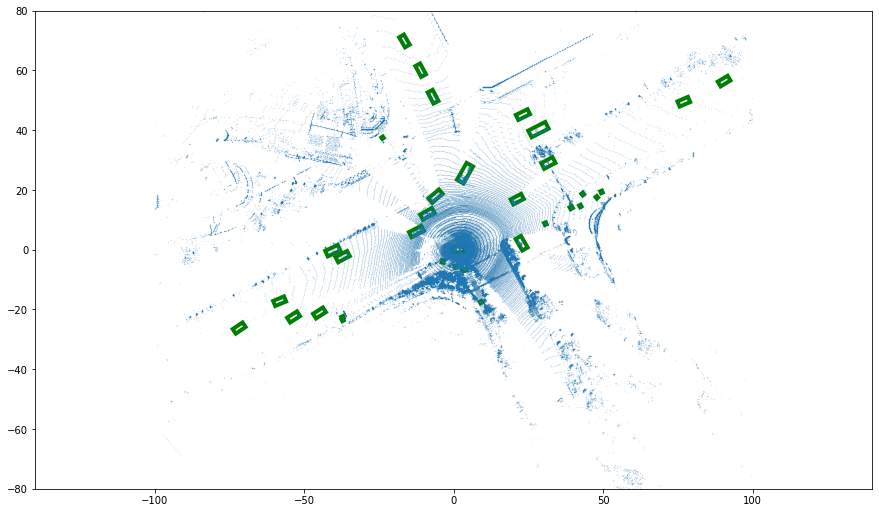

In [85]:
input_id = 1950163
inp = eng.get_input(input_id)
input_internal_id = inp.internal_id

pred, pointcloud = get_predictions(input_internal_id, threshold=0.2)

fig, ax = plt.subplots(figsize=(15,15))
ax.plot(pointcloud[:,0], pointcloud[:,1],'.', markersize=0.1)

for obj in pred:
    poly = bottom_corners(obj)
    ax.add_patch(Polygon(poly, edgecolor = 'green', fill=False,lw=4,closed=True))
    
ax.set_aspect('equal');
ax.set_xlim([-140, 140]);
ax.set_ylim([-80, 80]);

# Create preannotated assignment

In [51]:
# blob = generate_preannotation_blob(pred)
# assignment = eng.create_pre_annotation(input_id=input_id, request_id=request_id, content=blob, task_definition_id=task_definition_id, task_definition_revision_id=task_definition_revision_id)
# print(assignment.id)

7941846
